In [16]:
import os
import re
import xarray as xr
import numpy as np
import itertools
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.dates as mdates
from pathlib import Path
from datetime import timedelta
import matplotlib.pyplot as plt
import ssam_groups as groups

In [2]:
# Read in salish sea atlantis output files.
control_file = "/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/Control/highres-control-3y-2039-2042/outputSalishSea.nc"
control = xr.open_dataset(str(control_file), decode_cf=True)
time = np.ma.filled(control.variables['t'])

In [3]:
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/')

## All Scenarios

In [4]:
Turn_Point = [1, 2, 3, 4, 5, 8, 9, 33, 34, 37, 60, 66]
Active_Pass = [33, 60, 63]
English_Bay = [72, 74, 75, 80]
Jstrait = [1, 2] 

In [5]:
line_styles = itertools.cycle(('-', '--', '-.', ':'))#,(5, (10, 3)),
#    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))

In [7]:

scenario_paths = sorted([p for p in scenario_root.glob('highres-2039-2042_5b_*WSF*/outputSalishSea.nc')])
scenario_names = []
for path in scenario_paths:
    print(path.parent.stem)
    nm = str(path.parent.stem).split(sep='_')
    if nm[1] == '4a':
        scenario_loc = 'AP'
    elif nm[1] == '5b':
        scenario_loc = 'TP'
    elif nm[1] == '6a':
        scenario_loc = 'EB'
    elif nm[1] == '7a':
        scenario_loc = 'JF'
    scenario_names.append(scenario_loc+'-'+str(nm[4]))

highres-2039-2042_5b_3_2020-01-24_WSFmax-Aggregated
highres-2039-2042_5b_3_2020-01-24_WSFmax-Conservative
highres-2039-2042_5b_3_2020-01-24_WSFmin-Aggregated
highres-2039-2042_5b_3_2020-01-24_WSFmin-Conservative


In [8]:
print(scenario_names)

['TP-WSFmax-Aggregated', 'TP-WSFmax-Conservative', 'TP-WSFmin-Aggregated', 'TP-WSFmin-Conservative']


In [9]:
scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in scenario_paths]

In [10]:
start = 0
end = time.size-1

In [11]:
sensitivity = {
    'dogfish':0.1,'ratfish':0.1, 'sixgill':0.1, 'skates':0.1,
    'seagulls':1.3, 'other seabirds':0.2,
    'Harbor_porpoise':0.4, 'Harbor_seals':0.1, 'Humpback_whales':0.1,'Sealions':0.3,
    'Orcas_resident':0.1, 'Orcas_transient':0.1,
    'benthopelagic':0.2, 'small pelagic':1.1, 'small demersal':0.1, 
    'large demersal':0.3, 'small flatfish':0.6, 'large flatfish':0.1,
    'hake':0.4,'lingcod':0.1, 'pollock':0.1, 'sandlance':0.6, 
    'rockfish':1.2, 'Pacific_herring':0.2,
    'Chinook_salmon':0.4, 'Chum_salmon':0.4, 'Coho_salmon':0.1,'Pink_salmon':0.1, 'Sockeye_salmon':0.7, 
    'Hatchery_Chinook_salmon':0.1,'Hatchery_Coho_salmon':0.1,'Hatchery_Sockeye_salmon':0.2, 
    'Other salmonids':0.1, 'Macroalgae':1.4, 'Seagrass':6.1,

    'benthic_invertebrates':0.5,'vegetation':2, 'birds':1.2, 'cetaceans':0.4, 'salmon':0.6,
    'demersal_fish'	:0.2,'pelagic_fish'	:0.3,'pinnipeds':0.1,'plankton':0.1,'elasmobranchs':0.1,

    'Carniv_Zoo':9.0, 'Gelat_Zoo':0.7, 'MicroZoo':5.5,
    'Zoo':0.2, 'Zooplankton':0.2, 'Diatom':0.1, 'PicoPhytopl':0.3, 'Phytoplankton':0.3,
    'Pelag_Bact':0.1,
}

In [14]:
def heatmap_pelagic(bio_group, location=groups.salish_sea, v_min=None, v_max=None):
    all_results = []
    for scenario, path in zip(scenario_datasets, scenario_paths):
        nm = str(path.parent.stem).split(sep='_')
        scenario_name = str(nm[4])

        for species in bio_group:
            
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location, :], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location, :], np.nan)
            
            p_oiled = p_oiled.sum(axis=(1, 2)).mean()
            p_control = p_control.sum(axis=(1, 2)).mean()
            
            ratio = (p_oiled / p_control - 1) * 100

            all_results.append({
                'bio_group': bio_group[species],
                'scenario': scenario_name,
                'percent_change': ratio
            })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/heatmap-pelagic-WSF.csv")
    df_pivot = df.pivot_table(index='bio_group', 
                        columns='scenario', 
                        values='percent_change', 
                        )

    #sns.heatmap(df_pivot, annot=False, cmap='coolwarm_r', center=0)
    plt.figure(figsize=(14, len(df_pivot)*0.3))
    ax = sns.heatmap(df_pivot, annot=False, cmap='coolwarm_r', center=0, vmin=v_min, vmax=v_max,
    linewidths=0.5,
    #linecolor='gray',
    cbar_kws={'label': 'Percent Change'})
    location_boundaries = []
    prev_loc = None
    for i, col in enumerate(df_pivot.columns):
        loc = col.split('-')[0]
        if prev_loc is not None and loc != prev_loc:
            location_boundaries.append(i)
        prev_loc = loc

    for x in location_boundaries:
        ax.vlines(x, *ax.get_ylim(), colors='white', linewidth=4)

In [ ]:
heatmap_pelagic(groups.all_pelagic)

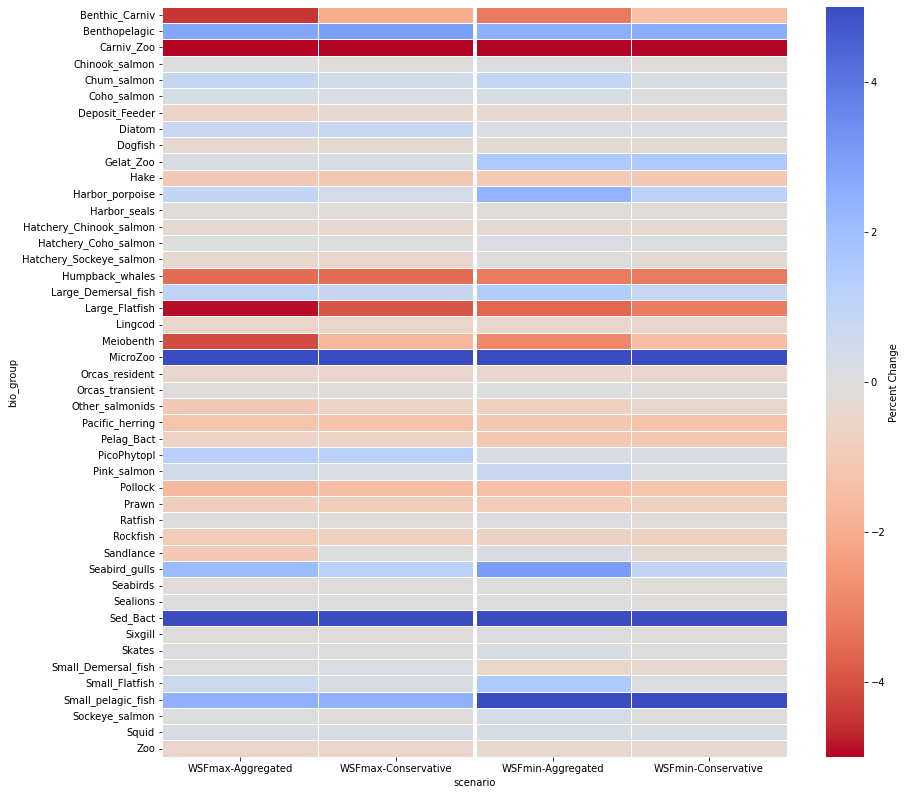

In [23]:
df = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/heatmap-pelagic-WSF.csv")
df_pivot = df.pivot_table(index='bio_group', 
                        columns='scenario', 
                        values='percent_change', 
                        )

#sns.heatmap(df_pivot, annot=False, cmap='coolwarm_r', center=0)
plt.figure(figsize=(14, len(df_pivot)*0.3))
ax = sns.heatmap(df_pivot, annot=False, cmap='coolwarm_r', center=0, vmin=-5, vmax=5,
    linewidths=0.5,
    #linecolor='gray',
    cbar_kws={'label': 'Percent Change'})
location_boundaries = []
prev_loc = None
for i, col in enumerate(df_pivot.columns):
    loc = col.split('-')[0]
    if prev_loc is not None and loc != prev_loc:
        location_boundaries.append(i)
    prev_loc = loc

for x in location_boundaries:
    ax.vlines(x, *ax.get_ylim(), colors='white', linewidth=4)

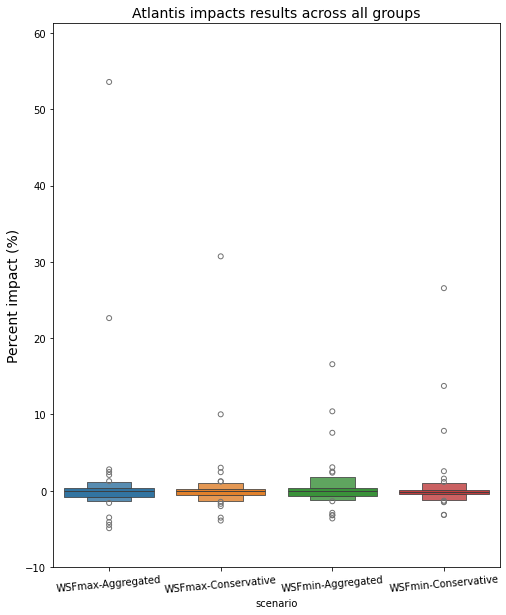

In [126]:
plt.figure(figsize=(8, 10))
ax = sns.boxenplot(df_pivot) 
plt.ylim(-10)
plt.ylabel('Percent impact (%)', fontsize = 14)
plt.title('Atlantis impacts results across all groups', fontsize = 14)
plt.xticks(rotation=5);

In [70]:
max_min_c = df_pivot['WSFmax-Conservative'] - df_pivot['WSFmin-Conservative']
max_min_a = df_pivot['WSFmax-Aggregated'] - df_pivot['WSFmin-Aggregated']
agg_cons_h = df_pivot['WSFmax-Aggregated'] - df_pivot['WSFmax-Conservative']agg_con_l = df_pivot['WSFmin-Aggregated'] - df_pivot['WSFmin-Conservative']

In [113]:
diff_results = {'Solubility max-min_a': max_min_a,
                'Solubility max-min_c': max_min_c,
                'PAH agg-cons_hs': agg_cons_h,
                'PAH agg-cons_ls': agg_con_l,}


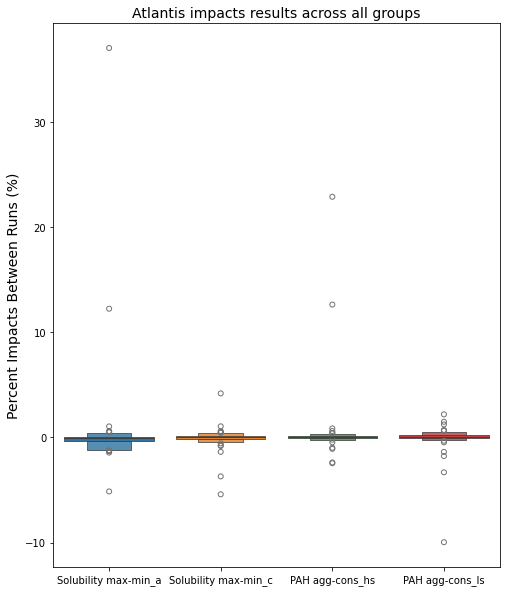

In [130]:
plt.figure(figsize=(8, 10))
ax = sns.boxenplot(diff_results) 
plt.ylabel('Percent Impacts Between Runs (%)', fontsize = 14)
plt.title('Atlantis impacts results across all groups', fontsize = 14);


In [ ]:
plt.figure(figsize=(8, 10))
ax = sns.boxenplot(diff_results) 
plt.ylim(-10, 7.5)
plt.ylabel('Percent Impacts Between Runs (%)', fontsize = 14)
plt.title('Atlantis impacts results across all groups', fontsize = 14);

In [131]:
max_min_a

bio_group
Benthic_Carniv             -1.255772
Benthopelagic               0.294389
Carniv_Zoo                 -0.003638
Chinook_salmon             -0.079136
Chum_salmon                 0.000046
Coho_salmon                -0.001094
Deposit_Feeder             -0.229640
Diatom                      0.591808
Dogfish                    -0.056950
Gelat_Zoo                  -1.318470
Hake                       -0.075032
Harbor_porpoise            -1.455310
Harbor_seals               -0.014868
Hatchery_Chinook_salmon    -0.059815
Hatchery_Coho_salmon       -0.115782
Hatchery_Sockeye_salmon    -0.357204
Humpback_whales            -0.316004
Large_Demersal_fish        -0.361704
Large_Flatfish             -1.277330
Lingcod                    -0.071860
Meiobenth                  -1.210625
MicroZoo                   12.219210
Orcas_resident             -0.025386
Orcas_transient            -0.072551
Other_salmonids            -0.324462
Pacific_herring            -0.136596
Pelag_Bact                  

In [128]:
max_min_c

bio_group
Benthic_Carniv            -0.575197
Benthopelagic              0.456960
Carniv_Zoo                -0.003946
Chinook_salmon             0.025106
Chum_salmon                0.216657
Coho_salmon                0.147250
Deposit_Feeder            -0.059532
Diatom                     0.588188
Dogfish                   -0.026857
Gelat_Zoo                 -1.382816
Hake                      -0.066574
Harbor_porpoise           -0.827252
Harbor_seals               0.016373
Hatchery_Chinook_salmon   -0.039443
Hatchery_Coho_salmon      -0.084221
Hatchery_Sockeye_salmon   -0.226459
Humpback_whales           -0.349680
Large_Demersal_fish        0.053460
Large_Flatfish            -0.759027
Lingcod                   -0.040507
Meiobenth                 -0.208320
MicroZoo                  -3.719338
Orcas_resident             0.004839
Orcas_transient           -0.023049
Other_salmonids           -0.177150
Pacific_herring           -0.010465
Pelag_Bact                 0.445107
PicoPhytopl       

In [132]:
agg_cons_h

bio_group
Benthic_Carniv             -2.464720
Benthopelagic              -0.215208
Carniv_Zoo                  0.000055
Chinook_salmon              0.102579
Chum_salmon                 0.412883
Coho_salmon                 0.140902
Deposit_Feeder             -0.229475
Diatom                      0.003173
Dogfish                    -0.069685
Gelat_Zoo                  -0.015558
Hake                        0.051700
Harbor_porpoise             0.593863
Harbor_seals                0.012496
Hatchery_Chinook_salmon     0.021151
Hatchery_Coho_salmon        0.034250
Hatchery_Sockeye_salmon     0.106414
Humpback_whales             0.017437
Large_Demersal_fish         0.223484
Large_Flatfish             -0.996970
Lingcod                     0.012103
Meiobenth                  -2.392273
MicroZoo                   12.611367
Orcas_resident              0.015625
Orcas_transient             0.046017
Other_salmonids            -0.478477
Pacific_herring             0.081332
Pelag_Bact                  

In [133]:
agg_con_l

bio_group
Benthic_Carniv            -1.784146
Benthopelagic             -0.052637
Carniv_Zoo                -0.000253
Chinook_salmon             0.206821
Chum_salmon                0.629494
Coho_salmon                0.289246
Deposit_Feeder            -0.059367
Diatom                    -0.000447
Dogfish                   -0.039593
Gelat_Zoo                 -0.079905
Hake                       0.060157
Harbor_porpoise            1.221921
Harbor_seals               0.043736
Hatchery_Chinook_salmon    0.041523
Hatchery_Coho_salmon       0.065811
Hatchery_Sockeye_salmon    0.237159
Humpback_whales           -0.016239
Large_Demersal_fish        0.638648
Large_Flatfish            -0.478667
Lingcod                    0.043457
Meiobenth                 -1.389967
MicroZoo                  -3.327181
Orcas_resident             0.045850
Orcas_transient            0.095519
Other_salmonids           -0.331164
Pacific_herring            0.207463
Pelag_Bact                -0.012839
PicoPhytopl       

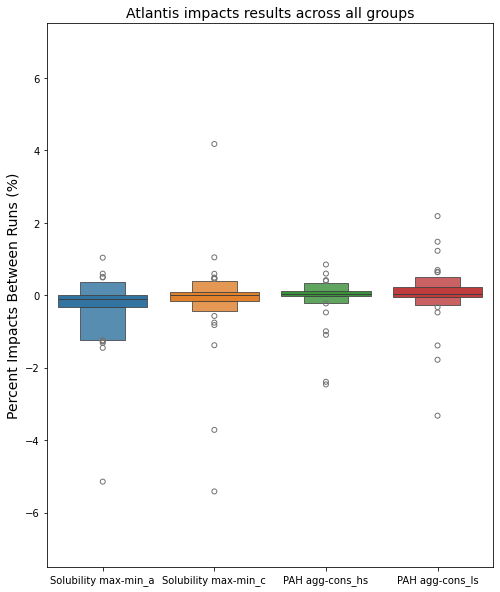

In [134]:
plt.figure(figsize=(8, 10))
ax = sns.boxenplot(diff_results) 
plt.ylim(-7.5, 7.5)
plt.ylabel('Percent Impacts Between Runs (%)', fontsize = 14)
plt.title('Atlantis impacts results across all groups', fontsize = 14);

### PAH Concentrations in Habitat

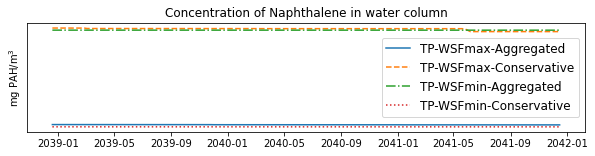

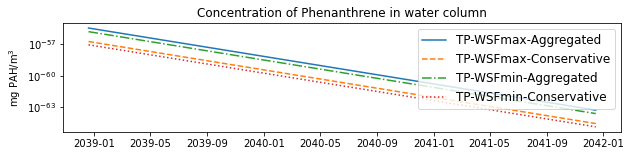

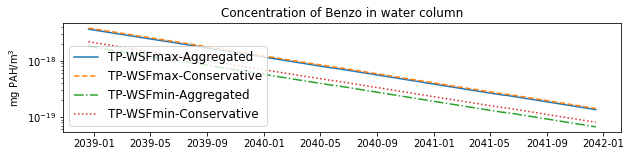

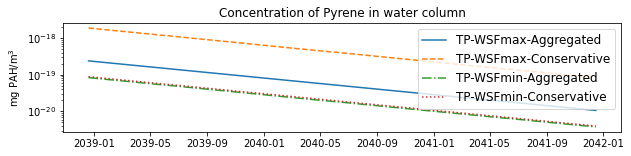

In [24]:
for pah in groups.pahs:
    fig, ax = plt.subplots(figsize = (10,2))
    for scenario, name in zip(scenario_datasets,scenario_names):
        contam_tbl = scenario.variables[str(pah)][start:end,:,0:6]
        contam_tb = contam_tbl.sum(axis=2)
        contam_t = contam_tb.sum(axis=1)
        # if 'AP' in name:
        #     hex_colour = '#863092'
        # elif 'TP' in name:
        #     hex_colour = '#6DB48E'
        # elif 'EB' in name:
        #     hex_colour = '#2F61A4'
        # elif 'JF' in name:
        #     hex_colour = '#A27170'
        ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles)) #color=hex_colour,
    ax.set_title('Concentration of '+ pah +' in water column', fontsize = 12)
    ax.set_ylabel('mg PAH/m$^3$')
    ax.legend(scenario_names, fontsize=12, ncol=1) #, bbox_to_anchor=(1.05, 1)) #loc='upper center', 

### PAH in biological groups

In [25]:
def plot_pelagic_pah(species,pah, scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None,ncol=1):
        fig, ax = plt.subplots(figsize = (8,2))
        for scenario, name in zip(scenario_datasets,scenario_names):
            contam_tb = scenario.variables[species+'_'+str(pah)][start:end,boxes,0:6]
            contam_t = contam_tb.sum(axis=(1,2))
            if 'AP' in name:
                hex_colour = '#863092'
            elif 'TP' in name:
                hex_colour = '#6DB48E'
            elif 'EB' in name:
                hex_colour = '#2F61A4'
            elif 'JF' in name:
                hex_colour = '#A27170'
            ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles)) #color=hex_colour, 
        ax.set_title('Concentration of '+ pah +' in '+ species, fontsize = 12)
        ax.set_ylabel('mg PAH/m$^3$')
        ax.legend(scenario_names, fontsize=12, ncol=ncol,bbox_to_anchor=(1.05, 1)); #loc='upper left', , loc='upper center', 

In [26]:
def plot_benthic_pah(species,pah, scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None,ncol=1):
        fig, ax = plt.subplots(figsize = (8,2))
        for scenario, name in zip(scenario_datasets,scenario_names):
            contam_tb = scenario.variables[species+'_'+str(pah)][start:end,boxes]
            contam_t = contam_tb.sum(axis=(1))
            if 'AP' in name:
                hex_colour = '#863092'
            elif 'TP' in name:
                hex_colour = '#6DB48E'
            elif 'EB' in name:
                hex_colour = '#2F61A4'
            elif 'JF' in name:
                hex_colour = '#A27170'
            ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles)) #color=hex_colour, 
        ax.set_title('Concentration of '+ pah +' in '+ species, fontsize = 12)
        ax.set_ylabel('mg PAH/m$^3$')
        ax.legend(scenario_names, fontsize=12, ncol=ncol,bbox_to_anchor=(1.05, 1)); #loc='upper left', bbox_to_anchor=(1.05, 1), loc='upper center', 

In [27]:
def plot_vertebrate_pah(species,pah, scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None,ncol=1):
        fig, ax = plt.subplots(figsize = (8,2))
        for scenario, name in zip(scenario_datasets,scenario_names):
            contam_tbl = 0
            for cohort in range (1, groups.cohorts[species]+1):
                contam_tbl = contam_tbl + scenario.variables[species+str(cohort)+'_'+str(pah)][start:end,boxes,0:6]
            contam_t = contam_tbl.sum(axis=(1,2))
            if 'AP' in name:
                hex_colour = '#863092'
            elif 'TP' in name:
                hex_colour = '#6DB48E'
            elif 'EB' in name:
                hex_colour = '#2F61A4'
            elif 'JF' in name:
                hex_colour = '#A27170'
            ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles)) #color=hex_colour, 
        ax.set_title('Concentration of '+ pah +' in '+ species, fontsize = 12)
        ax.set_ylabel('mg PAH/m$^3$')
        ax.legend(scenario_names, fontsize=12, ncol=ncol,bbox_to_anchor=(1.05, 1)); #loc='upper left', bbox_to_anchor=(1.05, 1), loc='upper center', 

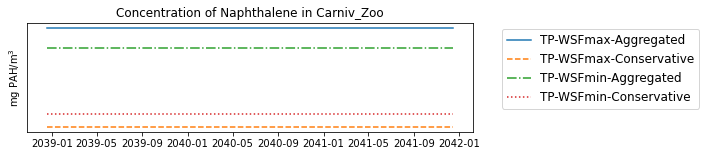

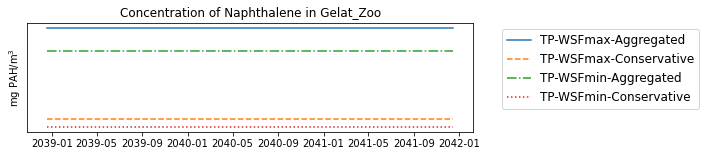

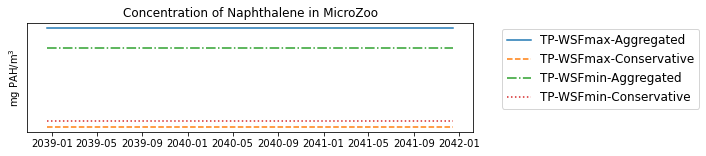

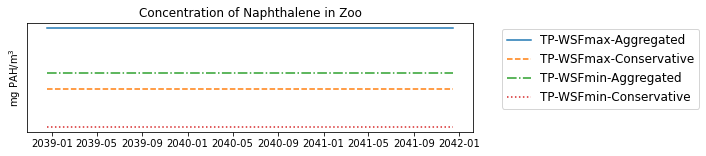

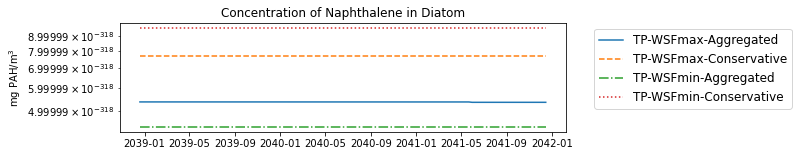

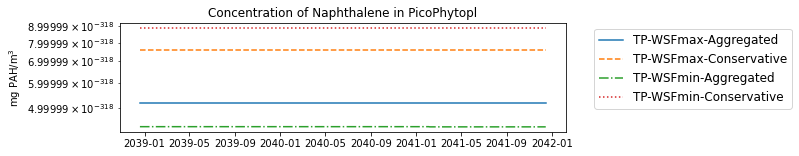

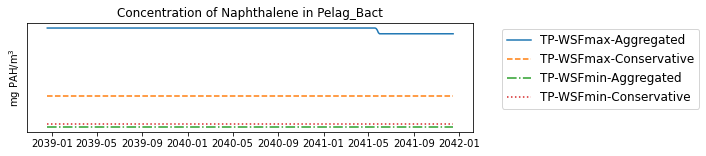

In [28]:
for species in groups.plankton:
    plot_pelagic_pah(groups.plankton[species], 'Naphthalene', ncol=1)

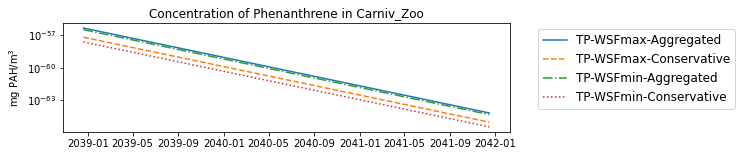

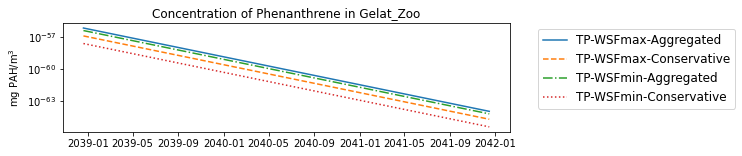

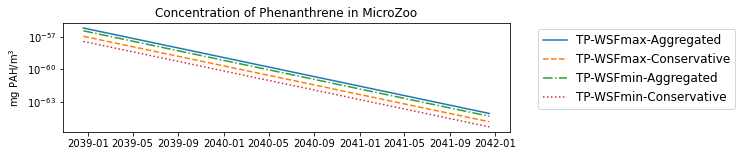

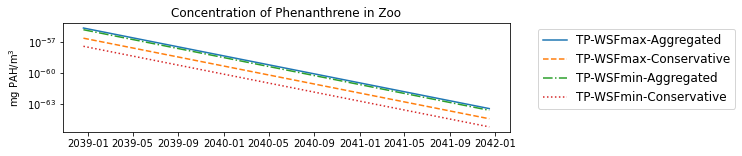

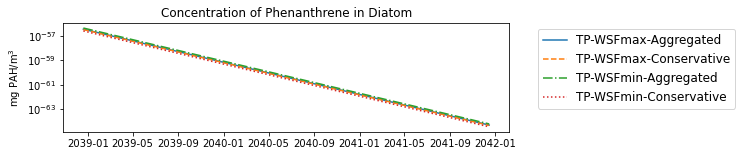

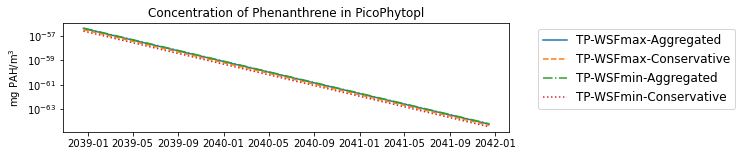

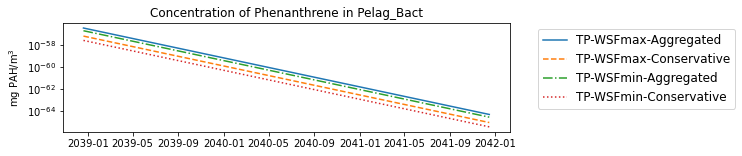

In [29]:
for species in groups.plankton:
    plot_pelagic_pah(groups.plankton[species], 'Phenanthrene', ncol=1)

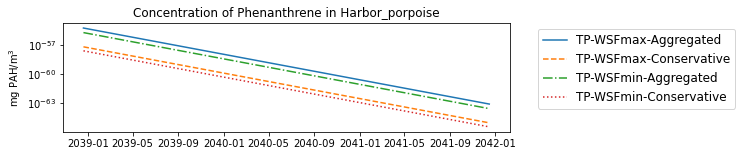

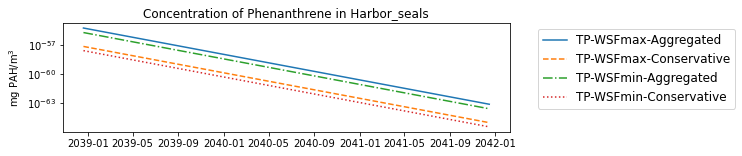

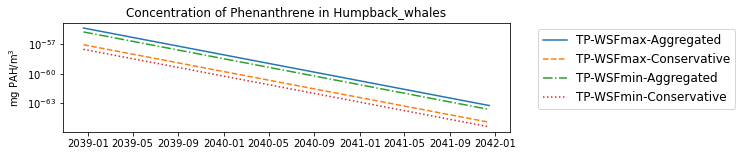

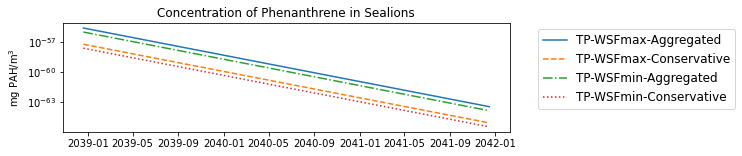

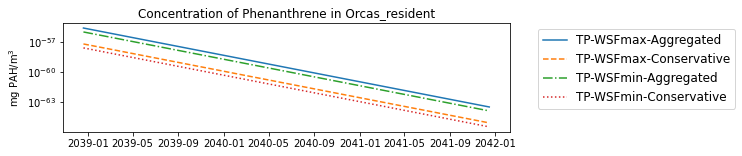

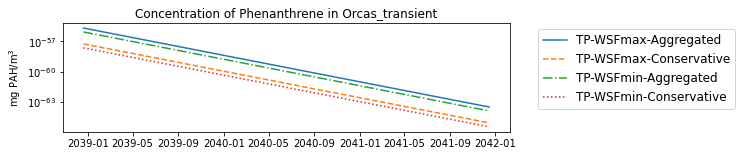

In [30]:
for species in groups.mammals:
    plot_vertebrate_pah(groups.mammals[species], 'Phenanthrene')

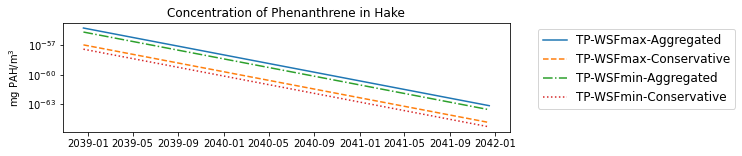

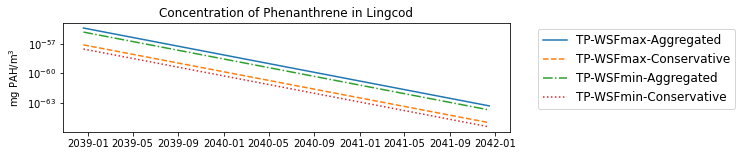

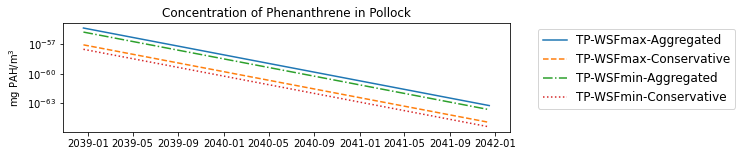

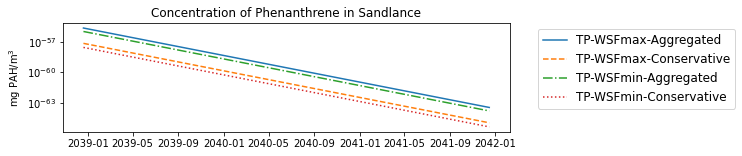

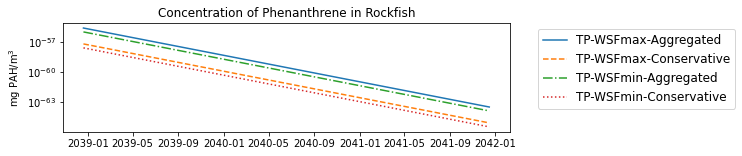

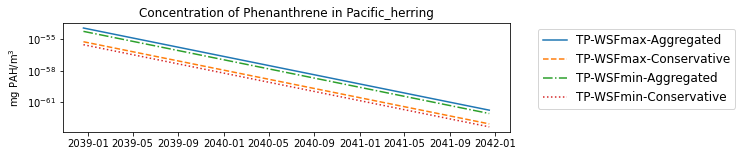

In [31]:
for species in groups.named_fish:
    plot_vertebrate_pah(groups.named_fish[species],'Phenanthrene')

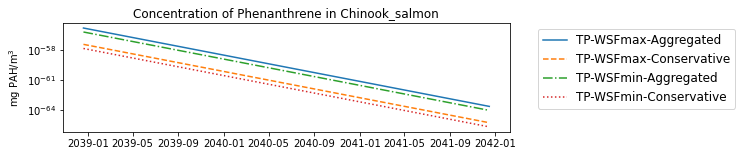

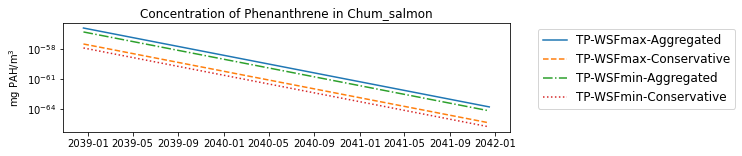

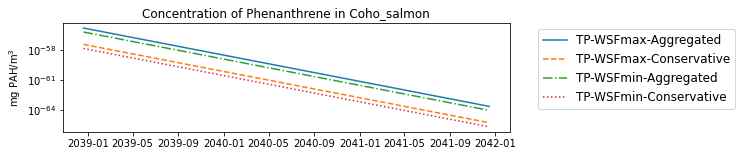

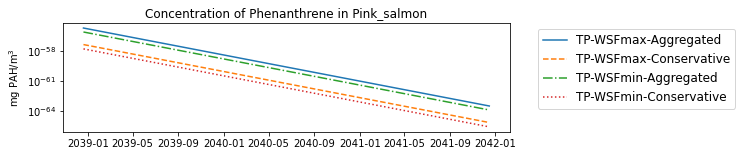

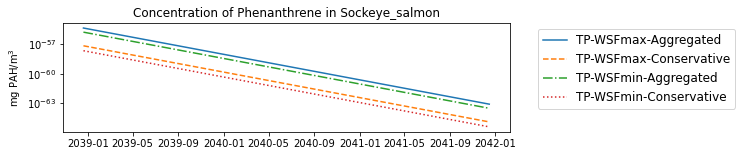

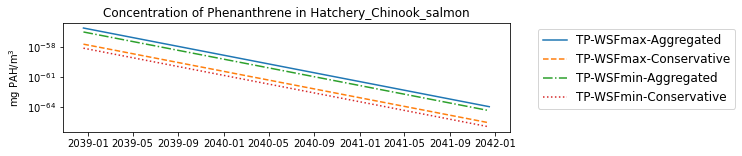

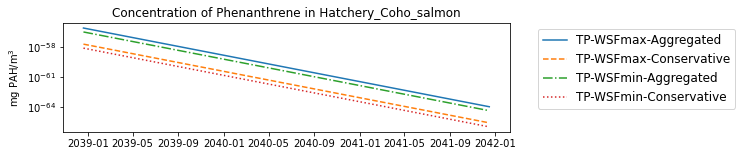

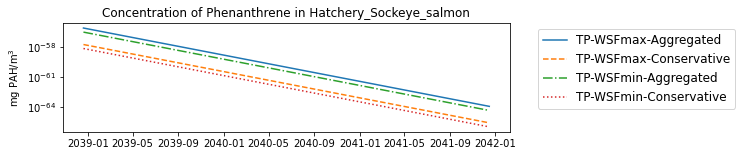

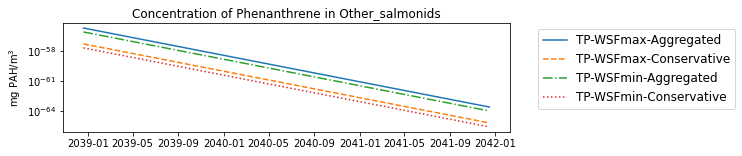

In [32]:
for species in groups.salmon:
    plot_vertebrate_pah(groups.salmon[species],'Phenanthrene')

### Impact results

In [33]:
def compare_scenario_pelagic(species, scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None,ncol=1): 
    
    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2))

    pelagic_control_tbl = np.ma.filled(control.variables[species+'_N'][start:end,boxes,0:6], np.nan)
    pelagic_control = pelagic_control_tbl.sum(axis=(1,2))
    control_ratio = (pelagic_control / pelagic_control-1)*100
    ax.plot(control.t[start:end], control_ratio, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        pelagic_oiled_tbl = np.ma.filled(scenario.variables[species+'_N'][start:end,boxes,0:6], np.nan)
        pelagic_oiled = pelagic_oiled_tbl.sum(axis=(1,2))
        ratio = (pelagic_oiled / pelagic_control-1)*100
        ax.plot(scenario.t[start:end], ratio, linewidth = 2, linestyle=next(line_styles)) #color=hex_colour,
    ax.fill_between(scenario.t[start:end], -sensitivity[species], sensitivity[species],
        color='grey', alpha=0.3, label='Model Sensitivity')

    plt.ylabel('Percent (%) change', fontsize=12)
    ax.set_title(species)
    ax.set_ylim([y_min, y_max])
    ax.legend(names, fontsize=12, ncol=ncol,bbox_to_anchor=(1.05, 1)); #bbox_to_anchor=(1.05, 1)

In [34]:
def compare_scenario_phytoplankton(scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None,ncol=1): 
    
    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2)) #14,5

    pelagic_control_tbl = np.ma.filled(control.variables['Diatom_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['PicoPhytopl_N'][start:end,boxes,0:6], np.nan)
    pelagic_control = pelagic_control_tbl.sum(axis=(1,2))
    control_ratio = (pelagic_control / pelagic_control-1)*100
    ax.plot(control.t[start:end], control_ratio, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        pelagic_oiled_tbl = np.ma.filled(scenario.variables['Diatom_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['PicoPhytopl_N'][start:end,boxes,0:6], np.nan)
        pelagic_oiled = pelagic_oiled_tbl.sum(axis=(1,2))
        ratio = (pelagic_oiled / pelagic_control-1)*100
        ax.plot(scenario.t[start:end], ratio, linewidth = 2, linestyle=next(line_styles)) #color=hex_colour, 
    ax.fill_between(scenario.t[start:end], -sensitivity['Phytoplankton'], sensitivity['Phytoplankton'],
        color='grey', alpha=0.3, label='Model Sensitivity')
    
    plt.ylabel('Percent (%) change', fontsize=12)
    ax.set_title('Phytoplankton')
    ax.set_ylim([y_min, y_max])
    ax.legend(names, fontsize=12, bbox_to_anchor=(1.05, 1),ncol=ncol); #bbox_to_anchor=(1.05, 1)

In [35]:
def compare_scenario_zooplankton(scenario_datasets=scenario_datasets, scenario_names=scenario_names, boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None,ncol=1): 
    
    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2))

    pelagic_control_tbl = np.ma.filled(control.variables['MicroZoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['Carniv_Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['Gelat_Zoo_N'][start:end,boxes,0:6], np.nan)
    pelagic_control = pelagic_control_tbl.sum(axis=(1,2))
    control_ratio = (pelagic_control / pelagic_control-1)*100
    ax.plot(control.t[start:end], control_ratio, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        pelagic_oiled_tbl = np.ma.filled(scenario.variables['MicroZoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['Carniv_Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['Gelat_Zoo_N'][start:end,boxes,0:6], np.nan)
        pelagic_oiled = pelagic_oiled_tbl.sum(axis=(1,2))
        ratio = (pelagic_oiled / pelagic_control-1)*100
        ax.plot(scenario.t[start:end], ratio, linewidth = 2, linestyle=next(line_styles)) #color=hex_colour, 
    ax.fill_between(scenario.t[start:end], -sensitivity['Zooplankton'], sensitivity['Zooplankton'],
        color='grey', alpha=0.3, label='Model Sensitivity')
    
    plt.ylabel('Percent (%) change', fontsize=12)
    ax.set_title('Zooplankton')
    ax.set_ylim([y_min, y_max])
    ax.legend(names, fontsize=12, bbox_to_anchor=(1.05, 1),ncol=ncol); #bbox_to_anchor=(1.05, 1), loc='lower right'

In [36]:
def plot_scenario_biomass_phytoplankton(scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None, ncol=1, alpha=0.6, savepath=None): 
    
    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2))

    pelagic_control_tbl = np.ma.filled(control.variables['Diatom_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['PicoPhytopl_N'][start:end,boxes,0:6], np.nan)
    pelagic_control = pelagic_control_tbl.sum(axis=(1,2))
    #control_ratio = (pelagic_control / pelagic_control-1)*100
    ax.plot(control.t[start:end], pelagic_control, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        pelagic_oiled_tbl = np.ma.filled(scenario.variables['Diatom_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['PicoPhytopl_N'][start:end,boxes,0:6], np.nan)
        pelagic_oiled = pelagic_oiled_tbl.sum(axis=(1,2))
        #ratio = (pelagic_oiled / pelagic_control-1)*100
        ax.plot(scenario.t[start:end], pelagic_oiled, linewidth = 2, alpha=alpha, linestyle=next(line_styles)) #color=hex_colour, 
    #ax.fill_between(scenario.t[start:end], -0.3, 0.3,
        #color='grey', alpha=0.3, label='Model Sensitivity')
    
    plt.ylabel('Biomass (mg N)', fontsize=16)
    ax.set_title('Phytoplankton', fontsize=16)
    ax.set_ylim([y_min, y_max])
    ylabels = ax.get_yticklabels()
    xlabels = ax.get_xticklabels()
    plt.setp(xlabels, fontsize=14)
    plt.setp(ylabels, fontsize=14)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.grid(True, alpha=1)
    ax.legend(names, bbox_to_anchor=(1, 1.05), fontsize=14, ncol=ncol) #bbox_to_anchor=(1.05, 1)); #ncol=ncol
    

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')


In [37]:
def plot_scenario_biomass_zooplankton(scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None, ncol=1, alpha=0.6, savepath=None): 
    
    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2))

    pelagic_control_tbl = np.ma.filled(control.variables['MicroZoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['Carniv_Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['Gelat_Zoo_N'][start:end,boxes,0:6], np.nan)
    pelagic_control = pelagic_control_tbl.sum(axis=(1,2))
    #control_ratio = (pelagic_control / pelagic_control-1)*100
    ax.plot(control.t[start:end], pelagic_control, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        pelagic_oiled_tbl = np.ma.filled(scenario.variables['MicroZoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['Carniv_Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['Gelat_Zoo_N'][start:end,boxes,0:6], np.nan)
        pelagic_oiled = pelagic_oiled_tbl.sum(axis=(1,2))
        #ratio = (pelagic_oiled / pelagic_control-1)*100
        ax.plot(scenario.t[start:end], pelagic_oiled, linewidth = 2, alpha=alpha, linestyle=next(line_styles)) #color=hex_colour, 
    #ax.fill_between(scenario.t[start:end], -0.3, 0.3,
        #color='grey', alpha=0.3, label='Model Sensitivity')
    
    #plt.ylabel('Biomass (mg N)', fontsize=16)
    ax.set_title('Zooplankton', fontsize=16)
    ax.set_ylim([y_min, y_max])
    ylabels = ax.get_yticklabels()
    xlabels = ax.get_xticklabels()
    plt.setp(xlabels, fontsize=14)
    plt.setp(ylabels, fontsize=14)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.grid(True, alpha=1)
    ax.legend(names, fontsize=14, bbox_to_anchor=(1.05, 1), ncol=ncol) #bbox_to_anchor=(1, 1.05),  bbox_to_anchor=(1.05, 1)); #ncol=ncol 

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')

In [38]:
def compare_scenario_vertebrates(bio_group, scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None): 
    
    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2)) #14,5

    pelagic_control_tbl = np.ma.filled(control.variables[bio_group + '_N'][start:end,boxes,0:6], np.nan)
    pelagic_control = pelagic_control_tbl.sum(axis=(1,2))
    control_ratio = (pelagic_control / pelagic_control-1)*100
    ax.plot(control.t[start:end], control_ratio, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        sum_ratio = 0
        
        numCohorts = groups.cohorts[bio_group]
        for cohort in range (1, numCohorts+1):

            new_species = bio_group + str(cohort)
        
            o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][start:end, boxes, 0:6], np.nan)
            o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][start:end, boxes, 0:6], np.nan)
            o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][start:end, boxes, 0:6], np.nan)

            c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][start:end, boxes, 0:6], np.nan)
            c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][start:end, boxes, 0:6], np.nan)
            c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][start:end, boxes, 0:6], np.nan)

            o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
            o_weightatage = o_weightatage_tbl.sum(axis=(1,2))

            c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
            c_weightatage = c_weightatage_tbl.sum(axis=(1,2))

            #difference = o_weightatage_tb.sum(axis=1) - c_weightatage_tb.sum(axis=1) 
            ratio = (o_weightatage / c_weightatage - 1) * 100
            #print(ratio)
            sum_ratio = sum_ratio + ratio

        ax.plot(scenario.t[start:end], sum_ratio/numCohorts, linewidth = 2, linestyle=next(line_styles)) #color=hex_colour, 
    ax.fill_between(scenario.t[start:end], -sensitivity[bio_group], sensitivity[bio_group],
        color='grey', alpha=0.3, label='Model Sensitivity')
    
    plt.ylabel('Percent (%) change', fontsize=12)
    ax.set_title(bio_group)
    ax.set_ylim([y_min, y_max])
    ax.legend(names, fontsize=12, bbox_to_anchor=(1.05, 1), ncol=1); #bbox_to_anchor=(1.05, 1), loc='lower right'

In [39]:
def compare_scenarios_benthic_N(species, scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None): 

    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2))

    pelagic_control = np.ma.filled(control.variables[species + '_N'][start:end,boxes], np.nan)
    pelagic_control = pelagic_control.sum(axis=1)
    control_ratio = (pelagic_control / pelagic_control-1)*100
    ax.plot(control.t[start:end], control_ratio, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        pelagic_oiled = np.ma.filled(scenario.variables[species + '_N'][start:end,boxes], np.nan) # tonnes
        pelagic_oiled = pelagic_oiled.sum(axis=1) 
        ratio = (pelagic_oiled / pelagic_control-1)*100
        ax.plot(scenario.t[start:end], ratio, linewidth = 2, linestyle=next(line_styles)) #color=hex_colour, 
    ax.fill_between(scenario.t[start:end], -sensitivity[species], sensitivity[species],
        color='grey', alpha=0.3, label='Model Sensitivity')
    
    plt.ylabel('Percent (%) change', fontsize=12)
    ax.set_title(species)
    ax.set_ylim([y_min, y_max])
    ax.legend(names, bbox_to_anchor=(1.05, 1), fontsize=12, ncol=1); #bbox_to_anchor=(1.05, 1), 

In [40]:
def plot_scenarios_biomass_benthic_N(species, scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None): 

    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2))

    pelagic_control = np.ma.filled(control.variables[species + '_N'][start:end,boxes], np.nan)
    pelagic_control = pelagic_control.sum(axis=1)
    ax.plot(control.t[start:end], pelagic_control, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        pelagic_oiled = np.ma.filled(scenario.variables[species + '_N'][start:end,boxes], np.nan) # tonnes
        pelagic_oiled = pelagic_oiled.sum(axis=1) 
        ax.plot(scenario.t[start:end], pelagic_oiled, linewidth = 2, linestyle=next(line_styles)) #color=hex_colour,
    
    plt.ylabel('Biomass (mg N)', fontsize=12)
    ax.set_title(species)
    ax.set_ylim([y_min, y_max])
    ax.legend(names, bbox_to_anchor=(1.05, 1), fontsize=12); #bbox_to_anchor=(1.05, 1), 

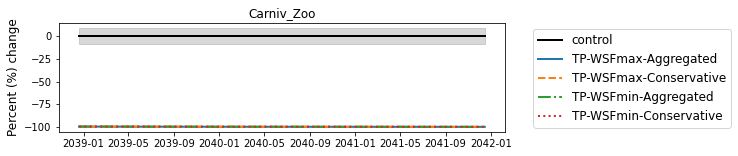

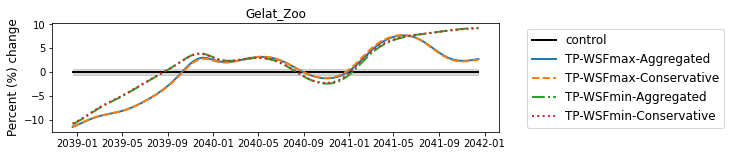

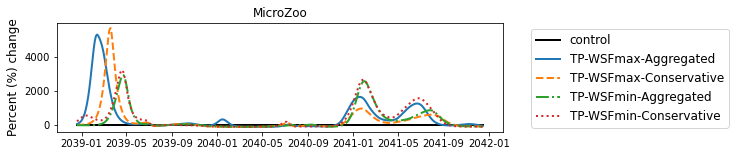

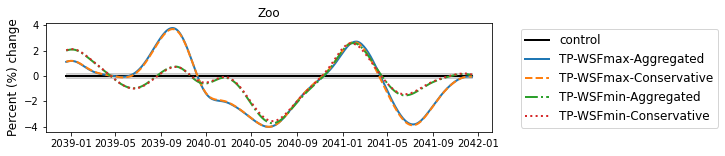

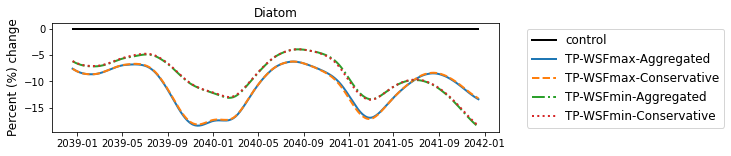

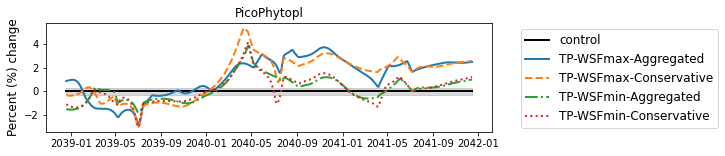

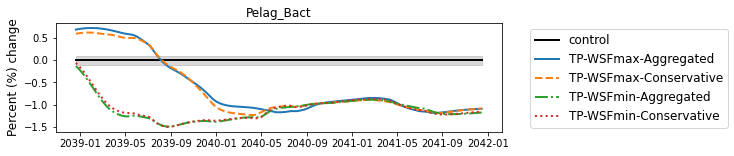

In [41]:
for species in groups.plankton:
    compare_scenario_pelagic(groups.plankton[species])

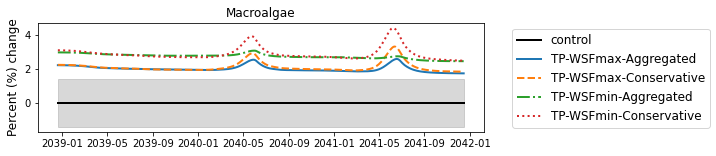

In [42]:
compare_scenarios_benthic_N('Macroalgae')

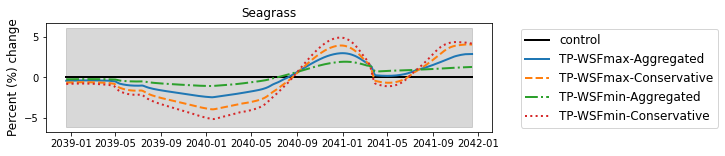

In [43]:
compare_scenarios_benthic_N('Seagrass')

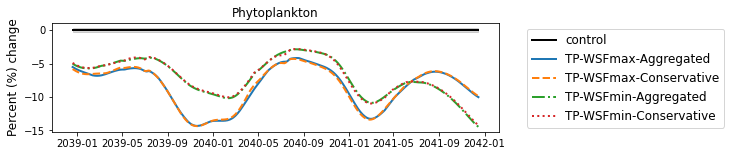

In [44]:
compare_scenario_phytoplankton()

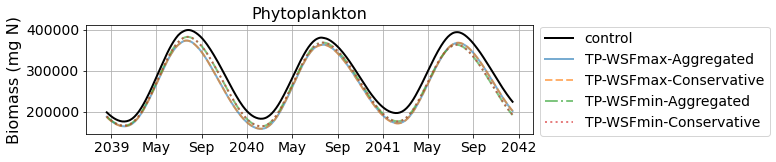

In [45]:
plot_scenario_biomass_phytoplankton()

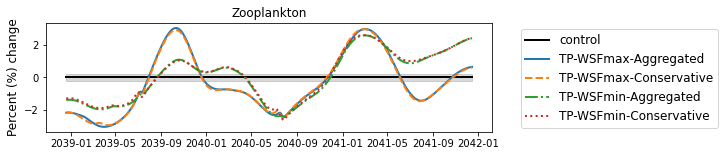

In [46]:
compare_scenario_zooplankton()

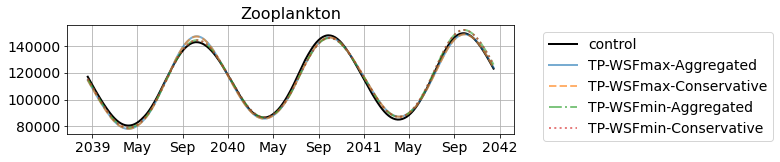

In [47]:
plot_scenario_biomass_zooplankton()

In [48]:
for species in groups.salmon:
    print(groups.salmon[species])

Chinook_salmon
Chum_salmon
Coho_salmon
Pink_salmon
Sockeye_salmon
Hatchery_Chinook_salmon
Hatchery_Coho_salmon
Hatchery_Sockeye_salmon
Other_salmonids


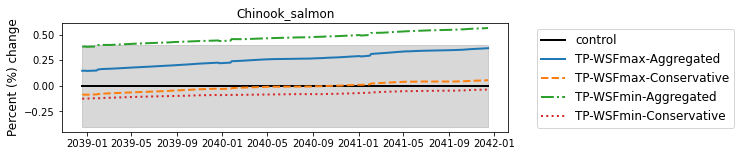

In [49]:
compare_scenario_vertebrates('Chinook_salmon')

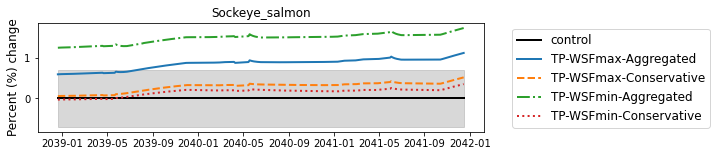

In [50]:
compare_scenario_vertebrates('Sockeye_salmon')

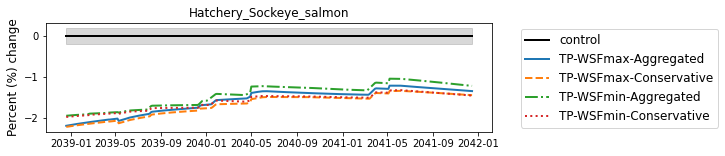

In [51]:
compare_scenario_vertebrates('Hatchery_Sockeye_salmon')

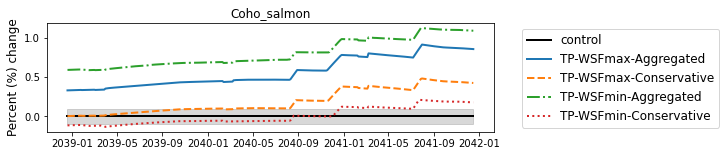

In [52]:
compare_scenario_vertebrates('Coho_salmon')

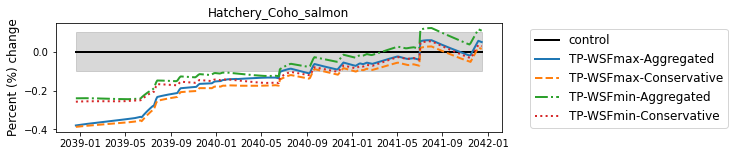

In [53]:
compare_scenario_vertebrates('Hatchery_Coho_salmon')

In [54]:
for species in groups.mammals:
    print(groups.mammals[species])

Harbor_porpoise
Harbor_seals
Humpback_whales
Sealions
Orcas_resident
Orcas_transient


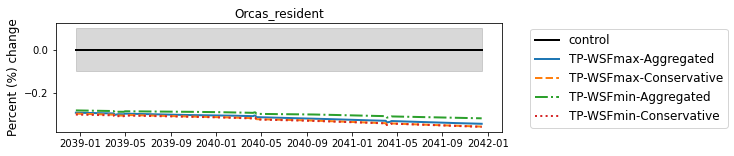

In [55]:
compare_scenario_vertebrates('Orcas_resident')

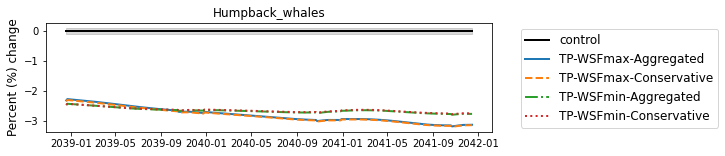

In [56]:
compare_scenario_vertebrates('Humpback_whales')